# Задача 1

In [ ]:
format ELF64
public _start

section '.data' writeable
    buf rb 20                 ; буфер под цифры числа
    nl db 10                  ; символ перевода строки

section '.text' executable
_start:
    mov rcx, [rsp]            ; argc
    cmp rcx, 2                ; нужен ровно один аргумент
    jl exit
    mov rsi, [rsp + 16]       ; argv[1] - указатель на строку
    movzx rax, byte [rsi]     ; ASCII-код первого символа
    call print_num
exit:
    mov rax, 60               ; sys_exit
    xor rdi, rdi
    syscall

;вход: rax - число для вывода
print_num:
    mov rdi, buf + 20         ; заполняем буфер с конца
    mov rbx, 10               ; делитель - основание СС
digit:
    xor rdx, rdx
    div rbx                   ; rax = частное, rdx = очередная цифра
    add dl, '0'               ; цифра -> ASCII
    dec rdi
    mov [rdi], dl
    test rax, rax             ; пока частное не ноль
    jnz digit
    mov rdx, buf + 20
    sub rdx, rdi              ; длина числа
    mov rsi, rdi
    mov rax, 1                ; sys_write
    mov rdi, 1                ; stdout
    syscall
    mov rax, 1                ; выводим '\n'
    mov rdi, 1
    mov rsi, nl
    mov rdx, 1
    syscall
    ret


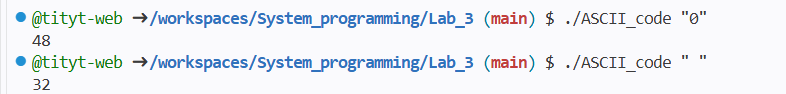

# Задача 2

дано (вариант 13):

$$((((b+c)+c)+a)+a)$$

In [ ]:
format ELF64
public _start

section '.data' writeable
    buf rb 20                 ; буфер под цифры результата
    nl db 10                  ; символ перевода строки

section '.text' executable
_start:
    mov rcx, [rsp]            ; argc
    cmp rcx, 4                ; нужны три аргумента: a, b, c
    jl exit
    mov rsi, [rsp + 16]       ; argv[1] -> a
    call str_to_int
    mov r8, rax               ; r8 = a
    mov rsi, [rsp + 24]       ; argv[2] -> b
    call str_to_int
    mov r9, rax               ; r9 = b
    mov rsi, [rsp + 32]       ; argv[3] -> c
    call str_to_int
    mov r10, rax              ; r10 = c

    mov rax, r9               ; b
    add rax, r10              ; (b+c)
    add rax, r10              ; ((b+c)+c)
    add rax, r8               ; (((b+c)+c)+a)
    add rax, r8               ; ((((b+c)+c)+a)+a)
    call print_num
exit:
    mov rax, 60               ; sys_exit
    xor rdi, rdi
    syscall

;вход: rsi - указатель на строку, выход: rax - число
str_to_int:
    xor rax, rax              ; накапливаемый результат
    mov rbx, 10               ; основание СС
next_char:
    movzx rcx, byte [rsi]     ; очередной символ
    test rcx, rcx             ; конец строки (0)
    jz done
    sub rcx, '0'              ; ASCII -> цифра
    mul rbx                   ; результат * 10
    add rax, rcx              ; + цифра
    inc rsi
    jmp next_char
done:
    ret

;вход: rax - число для вывода
print_num:
    mov rdi, buf + 20         ; заполняем буфер с конца
    mov rbx, 10               ; делитель - основание СС
digit:
    xor rdx, rdx
    div rbx                   ; rax = частное, rdx = очередная цифра
    add dl, '0'               ; цифра -> ASCII
    dec rdi
    mov [rdi], dl
    test rax, rax             ; пока частное не ноль
    jnz digit
    mov rdx, buf + 20
    sub rdx, rdi              ; длина числа
    mov rsi, rdi
    mov rax, 1                ; sys_write
    mov rdi, 1                ; stdout
    syscall
    mov rax, 1                ; выводим '\n'
    mov rdi, 1
    mov rsi, nl
    mov rdx, 1
    syscall
    ret


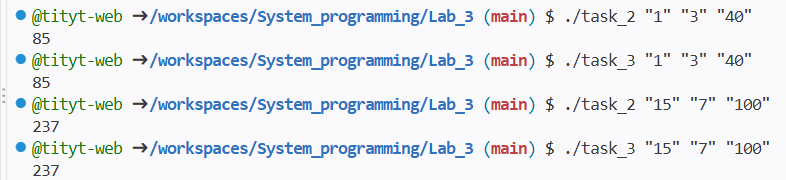

# Задача 3

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main(int argc, char *argv[]) {
    unsigned long a, b, c, result;

    if (argc != 4) {
        return 1;
    }

    a = strtoul(argv[1], NULL, 10);
    b = strtoul(argv[2], NULL, 10);
    c = strtoul(argv[3], NULL, 10);

    result = ((((b + c) + c) + a) + a);

    printf("%lu\n", result);

    return 0;
}


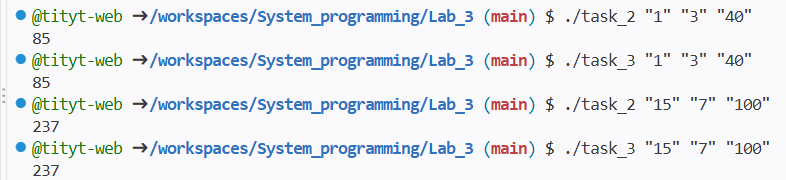